# RAG Masterclass: From Chunks to Generation
> **What this notebook covers:** Chunking → Embedding → Indexing → Retrieval → Reranking → Generation  
> Every concept explained with working code. Run cells top to bottom.

---
## Setup
Install everything you need:

In [11]:
# Run once — installs all dependencies
import subprocess
pkgs = [
    "sentence-transformers",
    "faiss-cpu",
    "rank-bm25",
    "numpy",
    "tiktoken",
    "openai",          # optional — for generation step
]
subprocess.run(["pip", "install", "-q"] + pkgs)
print("All packages installed.")

All packages installed.


In [12]:
import re, math, json, textwrap
import numpy as np
import warnings
warnings.filterwarnings("ignore")
print("Imports ready.")

Imports ready.


---
# Part 1 — Chunking

## Why Chunking Matters

A language model's embedding model converts text to a **fixed-size vector**.  
If you embed a 50-page document as one vector, the vector becomes a blurry average of every topic in the document — you lose signal.

**The core idea:** break documents into pieces small enough that each chunk is about *one thing*, large enough that each chunk has *enough context* to be meaningful on its own.

> **The retrieval unit = the context unit.**  
> Whatever you retrieve, you hand to the LLM. So chunks must be coherent standalone passages.

---
## The Rules of Good Chunking

| Rule | Why |
|---|---|
| Chunks should be semantically complete | A half-sentence or mid-paragraph cut loses meaning |
| Chunk size should match your embedding model's sweet spot | Most models are trained on 256–512 token passages |
| Add overlap between chunks | A key sentence might straddle a boundary — overlap ensures it appears in at least one full chunk |
| Don't mix content types in one chunk | Code + prose, table + prose — keep them separate |
| Metadata matters as much as the text | Source, section, page — these help filter at retrieval time |

---
## Strategy 1 — Fixed-Size (Word) Chunking
The simplest approach. Split by word count with a sliding window overlap.

Note: Embedding dimension = length of the vector

In [13]:
def chunk_fixed(text: str, chunk_size: int = 250, overlap: int = 50) -> list[dict]:
    """
    Sliding window over words.
    
    chunk_size : target words per chunk
    overlap    : words shared between adjacent chunks
    
    WHY overlap?
      Suppose a key sentence starts at word 248 of a 250-word chunk.
      Without overlap, the next chunk starts at word 251 and that
      sentence is split. With overlap=50, the next chunk starts at
      word 201, so that sentence appears in full in chunk N+1.
    """
    words = text.split()
    chunks = []
    start = 0
    chunk_id = 0

    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunk_text = " ".join(words[start:end])
        chunks.append({
            "id": chunk_id,
            "text": chunk_text,
            "start_word": start,
            "end_word": end,
            "word_count": end - start,
        })
        chunk_id += 1
        if end == len(words):
            break
        start += chunk_size - overlap   # step = chunk_size - overlap

    return chunks


# ── Demo ──
sample_text = """
Transformers are a type of neural network architecture that relies entirely on 
self-attention mechanisms to draw global dependencies between input and output.
Introduced in the paper "Attention Is All You Need" in 2017, they have since 
become the dominant architecture in natural language processing. Unlike recurrent 
neural networks, transformers process the entire sequence in parallel, making them 
much faster to train on modern hardware. The self-attention mechanism allows each 
token to attend to every other token in the sequence, capturing long-range 
dependencies that RNNs struggled with. BERT, GPT, and T5 are all transformer-based 
models that have achieved state-of-the-art results across many benchmarks.
Transformers have also been applied successfully to computer vision through models
like Vision Transformer (ViT), and to audio processing through models like Whisper.
""".strip()

chunks = chunk_fixed(sample_text, chunk_size=40, overlap=10)
for c in chunks:
    print(f"Chunk {c['id']} [{c['word_count']} words]: {c['text'][:80]}...")
    print()

Chunk 0 [40 words]: Transformers are a type of neural network architecture that relies entirely on s...

Chunk 1 [40 words]: Need" in 2017, they have since become the dominant architecture in natural langu...

Chunk 2 [40 words]: train on modern hardware. The self-attention mechanism allows each token to atte...

Chunk 3 [35 words]: are all transformer-based models that have achieved state-of-the-art results acr...



## Strategy 2 — Sentence-Aware Chunking
Better than pure word-count because it never cuts mid-sentence.  
Group N sentences per chunk. Still add overlap in sentences.

In [14]:
import re
def chunk_sentences(text: str, sentences_per_chunk: int = 5, overlap_sentences: int = 1) -> list[dict]:
    """
    Split on sentence boundaries, then group.
    
    sentences_per_chunk  : target sentences per chunk
    overlap_sentences    : sentences shared with next chunk
    
    WHY sentence boundaries?
      Sentences are the smallest semantically complete unit of text.
      Cutting inside a sentence creates a chunk that may not encode
      correctly — the model sees an incomplete thought.
    """
    # Split on sentence-ending punctuation followed by whitespace
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    sentences = [s.strip() for s in sentences if s.strip()]

    chunks = []
    step = max(1, sentences_per_chunk - overlap_sentences)
    
    for i in range(0, len(sentences), step):
        group = sentences[i : i + sentences_per_chunk]
        if not group:
            break
        chunks.append({
            "id": len(chunks),
            "text": " ".join(group),
            "sentence_start": i,
            "sentence_count": len(group),
        })

    return chunks


chunks_sent = chunk_sentences(sample_text, sentences_per_chunk=3, overlap_sentences=1)
for c in chunks_sent:
    print(f"Chunk {c['id']} [{c['sentence_count']} sentences]:")
    print(f"  {c['text'][:120]}...")
    print()

Chunk 0 [3 sentences]:
  Transformers are a type of neural network architecture that relies entirely on 
self-attention mechanisms to draw global...

Chunk 1 [3 sentences]:
  Unlike recurrent 
neural networks, transformers process the entire sequence in parallel, making them 
much faster to tra...

Chunk 2 [2 sentences]:
  BERT, GPT, and T5 are all transformer-based 
models that have achieved state-of-the-art results across many benchmarks. ...



## Strategy 3 — Recursive / Structural Chunking
The **best general-purpose strategy**. Split on structural boundaries in order of preference:  
paragraphs → sentences → words. Only go finer if the chunk is still too large.

This is what LangChain's `RecursiveCharacterTextSplitter` implements.  
We'll build the logic from scratch to see exactly what's happening.

In [15]:
def chunk_recursive(
    text: str,
    max_tokens: int = 400,
    overlap_tokens: int = 60,
    separators: list[str] = ["\n\n", "\n", ". ", " ", ""],
) -> list[dict]:
    """
    Recursively split on structural boundaries.
    
    separators (tried in order):
      "\n\n"  → paragraph break  (most preferred)
      "\n"    → line break
      ". "    → sentence end
      " "     → word boundary
      ""      → character (last resort, should never reach this)
    
    max_tokens : approx token limit per chunk (1 word ≈ 1.3 tokens)
    
    The algorithm:
      1. Try to split on the first separator.
      2. If any resulting piece is still too large, recurse with
         the next separator.
      3. Merge small adjacent pieces up to max_tokens (greedy merge).
    """
    def token_estimate(t: str) -> int:
        # Approximation: 1 token ≈ 4 characters (good enough without tiktoken)
        return len(t) // 4

    def split_and_merge(text: str, seps: list[str]) -> list[str]:
        if not seps:
            return [text]
        
        sep = seps[0]
        pieces = text.split(sep) if sep else list(text)
        pieces = [p for p in pieces if p.strip()]
        
        good, oversized = [], []
        for p in pieces:
            if token_estimate(p) > max_tokens:
                oversized.append(p)
            else:
                good.append(p)
        
        # Recurse on oversized pieces with next separator
        result = []
        for p in pieces:
            if token_estimate(p) > max_tokens:
                result.extend(split_and_merge(p, seps[1:]))
            else:
                result.append(p)
        
        # Greedy merge: combine small adjacent pieces
        merged, current, current_tokens = [], "", 0
        for piece in result:
            pt = token_estimate(piece)
            if current_tokens + pt <= max_tokens:
                current = (current + sep + piece).strip() if current else piece
                current_tokens += pt
            else:
                if current:
                    merged.append(current)
                current, current_tokens = piece, pt
        if current:
            merged.append(current)
        
        return merged

    raw_chunks = split_and_merge(text, separators)
    
    # Apply overlap: include last `overlap_tokens` chars of previous chunk
    chunks = []
    for i, chunk_text in enumerate(raw_chunks):
        if i > 0 and overlap_tokens > 0:
            prev = chunks[-1]["text"]
            overlap_text = prev[-overlap_tokens * 4:]   # approx chars
            chunk_text = overlap_text + " " + chunk_text
        chunks.append({
            "id": i,
            "text": chunk_text.strip(),
            "approx_tokens": token_estimate(chunk_text),
        })
    
    return chunks


chunks_rec = chunk_recursive(sample_text, max_tokens=80, overlap_tokens=20)
for c in chunks_rec:
    print(f"Chunk {c['id']} [~{c['approx_tokens']} tokens]: {c['text'][:100]}...")
    print()

Chunk 0 [~79 tokens]: Transformers are a type of neural network architecture that relies entirely on 
self-attention mecha...

Chunk 1 [~101 tokens]: ecome the dominant architecture in natural language processing. Unlike recurrent neural networks, tr...

Chunk 2 [~80 tokens]: pendencies that RNNs struggled with. BERT, GPT, and T5 are all transformer-based models that have ac...



## Chunking Strategy Decision Guide

```
What kind of content?
│
├── Prose (articles, books, docs)
│   ├── Needs heading structure?  → Structural / Markdown-aware chunking
│   └── Plain paragraphs?         → Recursive chunking  ✓ DEFAULT
│
├── Code
│   └── Split by function/class, never mid-block
│
├── Tables / CSV
│   └── Row-per-chunk or N rows, keep header in every chunk
│
└── PDFs with mixed layout
    └── Extract by page or bounding box, then recursive
```

**Token count to aim for:** 256–512 tokens per chunk.  
Most embedding models (OpenAI ada-002, BGE, E5) are trained on passages of this size.  
Going larger dilutes the signal. Going smaller loses context.

---
# Part 2 — Embedding

## What an Embedding Is

An embedding model converts a piece of text into a dense vector of floats — e.g. 384 or 1536 numbers.  
The model is trained so that **semantically similar texts produce vectors that are close together** in that space.

**Key principle:** we embed the query and every chunk with the **same model**.  
Retrieval = find chunk vectors closest to the query vector.

## Choosing an Embedding Model

| Model | Dims | Speed | Quality | Cost |
|---|---|---|---|---|
| `all-MiniLM-L6-v2` | 384 | Fast | Good | Free (local) |
| `BAAI/bge-small-en-v1.5` | 384 | Fast | Better | Free (local) |
| `BAAI/bge-large-en-v1.5` | 1024 | Slower | Best open-source | Free (local) |
| `text-embedding-ada-002` | 1536 | API call | Very good | Paid |
| `text-embedding-3-small` | 1536 | API call | Better | Paid |

> For most RAG systems: **`BAAI/bge-small-en-v1.5`** is the sweet spot — fast, small, outperforms MiniLM on benchmarks.

## One Critical Rule: Normalize Your Vectors

After embedding, **L2-normalize** every vector (make its magnitude = 1).  
Then dot product and cosine similarity become identical — and dot product is much faster to compute.

Dont product - Removes magnitude bias

A = [100, 0]

B = [1, 0]

Same direction → same meaning

But magnitudes different

In [16]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load model — downloads once, cached after that
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# Prepare our chunks from Part 1
corpus_texts = [
    "Transformers rely on self-attention to process sequences in parallel.",
    "BM25 is a keyword-based ranking function using TF-IDF with length normalization.",
    "HNSW builds a multi-layer graph for approximate nearest neighbor search.",
    "Chunking splits documents into pieces that each encode one coherent topic.",
    "Cross-encoders score query-document pairs jointly for high-precision reranking.",
    "RAG combines retrieval with generation to reduce hallucination.",
    "Cosine similarity measures the angle between two vectors, ignoring magnitude.",
    "Embedding models map text to dense vectors where similar texts are nearby.",
    "Product quantization compresses vectors from thousands of bytes to tens of bytes.",
    "Reranking filters a large candidate set down to the most relevant results.",
]

print("Embedding corpus...")
corpus_embeddings = model.encode(
    corpus_texts,
    normalize_embeddings=True,    # L2 normalize → dot product == cosine similarity
    show_progress_bar=True,
    batch_size=32,
)

print(f"\nEmbedding matrix shape: {corpus_embeddings.shape}")
print(f"Each vector: {corpus_embeddings.shape[1]} dimensions")
print(f"L2 norm of first vector: {np.linalg.norm(corpus_embeddings[0]):.4f}  (should be 1.0)")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4274.82it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding corpus...


Batches: 100%|██████████| 1/1 [00:00<00:00, 14.29it/s]


Embedding matrix shape: (10, 384)
Each vector: 384 dimensions
L2 norm of first vector: 1.0000  (should be 1.0)


In [17]:
# Let's look at what similarity actually means
query = "how does approximate nearest neighbor search work?"
query_embedding = model.encode([query], normalize_embeddings=True)

# Manual cosine similarity (dot product since we normalized)
similarities = corpus_embeddings @ query_embedding.T   # shape: (N, 1)
similarities = similarities.squeeze()

# Sort and display
ranked = sorted(zip(similarities, corpus_texts), reverse=True)

print(f"Query: '{query}'\n")
print("Ranked results (cosine similarity):")
for score, text in ranked:
    bar = "█" * int(score * 30)
    print(f"  {score:.3f} {bar}")
    print(f"         {text}")
    print()

Query: 'how does approximate nearest neighbor search work?'

Ranked results (cosine similarity):
  0.678 ████████████████████
         HNSW builds a multi-layer graph for approximate nearest neighbor search.

  0.386 ███████████
         Reranking filters a large candidate set down to the most relevant results.

  0.334 ██████████
         Cross-encoders score query-document pairs jointly for high-precision reranking.

  0.329 █████████
         Embedding models map text to dense vectors where similar texts are nearby.

  0.283 ████████
         BM25 is a keyword-based ranking function using TF-IDF with length normalization.

  0.283 ████████
         Cosine similarity measures the angle between two vectors, ignoring magnitude.

  0.263 ███████
         Product quantization compresses vectors from thousands of bytes to tens of bytes.

  0.130 ███
         Transformers rely on self-attention to process sequences in parallel.

  0.106 ███
         Chunking splits documents into pieces th

---
# Part 3 — Indexing

## Why You Need an Index

Brute-force similarity search is O(N × D) — for 1 million chunks of 768 dims, that's ~2.3 billion float multiplications per query. Too slow.

An index organizes vectors so you can skip most of them.  
The tradeoff: **speed vs recall** (exact answers vs approximate answers).

---
## Index Types

### Flat Index (Exact Search)
No approximation. Computes similarity against every vector.  
**When to use:** corpus < 100k, or when recall must be 100%.

### HNSW — The Best General-Purpose ANN Index
Builds a multi-layer graph. Upper layers = sparse, long-range connections.  
Lower layers = dense, local connections. Search starts at the top and descends.

**Key parameters:**
| Param | What it controls | Default | Higher value = |
|---|---|---|---|
| `M` | Edges per node | 16 | Better recall, more RAM |
| `ef_construction` | Build-time beam width | 200 | Better index, slower build |
| `ef_search` | Query-time beam width | 50 | Better recall, slower query |

**Rule of thumb:** `ef_search = max(top_k * 2, 50)` at query time.

### IVF-PQ — For Very Large Scale (10M+ vectors)
IVF clusters vectors into Voronoi cells. Query only searches `nprobe` nearest cells.  
PQ compresses each vector to ~32–64 bytes (from 3000+ bytes for 768-dim float32).  
Tradeoff: lower recall than HNSW, far less RAM.

In [18]:
import faiss
import numpy as np

# We'll reuse corpus_embeddings from Part 2
dim = corpus_embeddings.shape[1]   # 384 for MiniLM

# ── Index 1: Flat (exact, baseline) ──
flat_index = faiss.IndexFlatIP(dim)   # IP = inner product (= cosine for normalized vectors)
flat_index.add(corpus_embeddings.astype(np.float32))
print(f"Flat index: {flat_index.ntotal} vectors, exact search")

# ── Index 2: HNSW ──
M = 16                              # connections per node; 16 is a good default
hnsw_index = faiss.IndexHNSWFlat(dim, M, faiss.METRIC_INNER_PRODUCT)
hnsw_index.hnsw.efConstruction = 200   # set BEFORE adding vectors
hnsw_index.add(corpus_embeddings.astype(np.float32))
hnsw_index.hnsw.efSearch = 50          # set at query time; can be changed per query

print(f"HNSW index: {hnsw_index.ntotal} vectors, approximate search")
print(f"  M={M}, efConstruction=200, efSearch=50")

Flat index: 10 vectors, exact search
HNSW index: 10 vectors, approximate search
  M=16, efConstruction=200, efSearch=50


In [19]:
# ── Search both indexes and compare ──

query = "how does approximate nearest neighbor search work?"
query_vec = model.encode([query], normalize_embeddings=True).astype(np.float32)

top_k = 5

# Flat (exact)
scores_flat, ids_flat = flat_index.search(query_vec, top_k)
print("=== Flat (exact) results ===")
for score, idx in zip(scores_flat[0], ids_flat[0]):
    print(f"  [{score:.3f}] {corpus_texts[idx]}")

print()

# HNSW (approximate)
scores_hnsw, ids_hnsw = hnsw_index.search(query_vec, top_k)
print("=== HNSW (approximate) results ===")
for score, idx in zip(scores_hnsw[0], ids_hnsw[0]):
    print(f"  [{score:.3f}] {corpus_texts[idx]}")

print()
print("For small corpora, results should be identical.")
print("At scale, HNSW may miss a few — that's the approximation tradeoff.")

=== Flat (exact) results ===
  [0.678] HNSW builds a multi-layer graph for approximate nearest neighbor search.
  [0.386] Reranking filters a large candidate set down to the most relevant results.
  [0.334] Cross-encoders score query-document pairs jointly for high-precision reranking.
  [0.329] Embedding models map text to dense vectors where similar texts are nearby.
  [0.283] BM25 is a keyword-based ranking function using TF-IDF with length normalization.

=== HNSW (approximate) results ===
  [0.678] HNSW builds a multi-layer graph for approximate nearest neighbor search.
  [0.386] Reranking filters a large candidate set down to the most relevant results.
  [0.334] Cross-encoders score query-document pairs jointly for high-precision reranking.
  [0.329] Embedding models map text to dense vectors where similar texts are nearby.
  [0.283] BM25 is a keyword-based ranking function using TF-IDF with length normalization.

For small corpora, results should be identical.
At scale, HNSW may

In [20]:
# ── How ef_search controls the recall/speed tradeoff ──
# (Meaningful at scale; shown here for concept)

query_vec = model.encode(["nearest neighbor graph traversal"], normalize_embeddings=True).astype(np.float32)

print("ef_search | top-1 result")
print("-" * 60)
for ef in [10, 20, 50, 100, 200]:
    hnsw_index.hnsw.efSearch = ef
    scores, ids = hnsw_index.search(query_vec.astype(np.float32), 1)
    print(f"  {ef:>6}  | {corpus_texts[ids[0][0]][:70]}")

print()
print("At small scale ef_search makes no difference.")
print("At 10M+ vectors, ef=10 is 5-10x faster than ef=200 with ~2% recall drop.")

ef_search | top-1 result
------------------------------------------------------------
      10  | HNSW builds a multi-layer graph for approximate nearest neighbor searc
      20  | HNSW builds a multi-layer graph for approximate nearest neighbor searc
      50  | HNSW builds a multi-layer graph for approximate nearest neighbor searc
     100  | HNSW builds a multi-layer graph for approximate nearest neighbor searc
     200  | HNSW builds a multi-layer graph for approximate nearest neighbor searc

At small scale ef_search makes no difference.
At 10M+ vectors, ef=10 is 5-10x faster than ef=200 with ~2% recall drop.


---
# Part 4 — BM25 and Hybrid Retrieval

## Why Vector Search Alone Isn't Enough

Vector search captures **semantic similarity** — paraphrases, synonyms, related concepts.  
But it blurs over **exact tokens**. 

Example:  
- Query: `"error code E_CONN_TIMEOUT_503"`  
- Vector search: might return "connection failures" (semantically related but wrong error code)  
- BM25: returns the exact chunk mentioning `E_CONN_TIMEOUT_503`

**BM25 (Best Match 25)** is a probabilistic keyword ranking function.  
It scores by term frequency and inverse document frequency, with length normalization.

## BM25 Score Formula

$$\text{score}(d, q) = \sum_{t \in q} \text{IDF}(t) \cdot \frac{f(t,d) \cdot (k_1 + 1)}{f(t,d) + k_1 \cdot (1 - b + b \cdot \frac{|d|}{\text{avgdl}})}$$

Where:  
- `f(t,d)` = term frequency in document  
- `|d|` = document length, `avgdl` = average doc length  
- `k1 = 1.5` (TF saturation — after this many hits, diminishing returns)  
- `b = 0.75` (length normalization strength)

## Reciprocal Rank Fusion (RRF)

You can't just average BM25 and cosine scores — they're on different scales.  
RRF solves this: it only uses **ranks**, not raw scores.

$$\text{RRF}(d) = \sum_{i} \frac{1}{k + \text{rank}(d, \text{list}_i)}$$

`k = 60` is the canonical default from the original paper.

In [21]:
from rank_bm25 import BM25Okapi

def tokenize(text: str) -> list[str]:
    """Simple whitespace + lowercase tokenizer."""
    return re.findall(r'\b\w+\b', text.lower())

# Build BM25 index over our corpus
tokenized_corpus = [tokenize(t) for t in corpus_texts]
bm25 = BM25Okapi(tokenized_corpus, k1=1.5, b=0.75)

# BM25 search
query = "keyword ranking term frequency document length"
scores_bm25 = bm25.get_scores(tokenize(query))

print(f"Query: '{query}'\n")
print("BM25 results:")
ranked_bm25 = sorted(zip(scores_bm25, corpus_texts), reverse=True)
for score, text in ranked_bm25[:5]:
    print(f"  [{score:.3f}] {text}")

Query: 'keyword ranking term frequency document length'

BM25 results:
  [5.119] BM25 is a keyword-based ranking function using TF-IDF with length normalization.
  [1.846] Cross-encoders score query-document pairs jointly for high-precision reranking.
  [0.000] Transformers rely on self-attention to process sequences in parallel.
  [0.000] Reranking filters a large candidate set down to the most relevant results.
  [0.000] RAG combines retrieval with generation to reduce hallucination.


In [22]:
def reciprocal_rank_fusion(
    *ranked_lists: list[tuple],   # each tuple: (text, score, id)
    k: int = 60
) -> list[tuple]:
    """
    Merge N ranked lists using RRF.
    k=60 is the standard default — reduces influence of top-ranked outliers.
    
    Returns list of (text, rrf_score, id) sorted by rrf_score descending.
    """
    doc_scores: dict[int, float] = {}
    doc_texts:  dict[int, str]   = {}

    for ranked_list in ranked_lists:
        for rank, (text, _score, doc_id) in enumerate(ranked_list):
            rrf_score = 1.0 / (k + rank + 1)   # rank is 0-indexed
            doc_scores[doc_id] = doc_scores.get(doc_id, 0.0) + rrf_score
            doc_texts[doc_id]  = text

    sorted_ids = sorted(doc_scores, key=lambda d: doc_scores[d], reverse=True)
    return [(doc_texts[d], round(doc_scores[d], 5), d) for d in sorted_ids]


# ── Build search results from both indexes ──

query = "how does BM25 rank documents?"
query_vec = model.encode([query], normalize_embeddings=True).astype(np.float32)

# Vector results: list of (text, score, id)
scores_v, ids_v = flat_index.search(query_vec, len(corpus_texts))
vector_results = [(corpus_texts[i], float(s), int(i)) for s, i in zip(scores_v[0], ids_v[0]) if i >= 0]

# BM25 results
raw_bm25 = bm25.get_scores(tokenize(query))
bm25_results = sorted(
    [(corpus_texts[i], float(raw_bm25[i]), i) for i in range(len(corpus_texts))],
    key=lambda x: x[1], reverse=True
)

# Fuse
fused = reciprocal_rank_fusion(vector_results, bm25_results)

print(f"Query: '{query}'\n")
print(f"{'Rank':<5} {'RRF Score':<12} Text")
print("-" * 75)
for rank, (text, score, doc_id) in enumerate(fused[:6]):
    print(f"{rank+1:<5} {score:<12.5f} {text[:65]}")

Query: 'how does BM25 rank documents?'

Rank  RRF Score    Text
---------------------------------------------------------------------------
1     0.03252      BM25 is a keyword-based ranking function using TF-IDF with length
2     0.03202      Chunking splits documents into pieces that each encode one cohere
3     0.03151      Cross-encoders score query-document pairs jointly for high-precis
4     0.03078      HNSW builds a multi-layer graph for approximate nearest neighbor 
5     0.03016      Reranking filters a large candidate set down to the most relevant
6     0.03016      Transformers rely on self-attention to process sequences in paral


---
# Part 5 — Reranking

## The Problem Reranking Solves

After retrieval you have ~50 candidates. They're ranked by **vector similarity** — a blunt proxy for relevance.

Two reasons vector similarity falls short:  
1. The query and chunk were encoded **independently** — the model never sees them together.  
2. Cosine similarity measures *semantic neighborhood*, not *answer-to-question fit*.

A **cross-encoder** fixes both problems by reading the query and document *jointly*.

---
## Bi-encoder vs Cross-encoder

| | Bi-encoder | Cross-encoder |
|---|---|---|
| How it works | Query → vector, Doc → vector, compare | [Query + Doc] → single relevance score |
| Speed | O(1) per query (vectors pre-computed) | O(N) forward passes |
| Accuracy | Approximate | High |
| Use for | Retrieval over millions of docs | Reranking top 50–100 candidates |

## Why Cross-Entropy Loss?

Cross-encoders are trained as classifiers:  
- Input: (query, document) pair  
- Label: 1 if relevant, 0 if not  

Loss = **cross-entropy** over softmax of scores across all documents in the batch.

$$\mathcal{L} = -\log \frac{e^{s_{\text{relevant}}}}{\sum_i e^{s_i}}$$

At inference: use raw logit scores to rank. Don't apply softmax — you want the ordering, not probabilities.

In [23]:
from sentence_transformers import CrossEncoder

# Load a lightweight cross-encoder (fast, good quality)
# Options:
#   cross-encoder/ms-marco-MiniLM-L-6-v2  ← fast, this demo
#   cross-encoder/ms-marco-MiniLM-L-12-v2 ← more accurate
#   BAAI/bge-reranker-large               ← best open-source, slower
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", max_length=512)
print("Reranker loaded.")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 3138.62it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Reranker loaded.


In [24]:
query = "how does approximate nearest neighbor search work?"

# Step 1: Get top-20 candidates from vector search (fast)
query_vec = model.encode([query], normalize_embeddings=True).astype(np.float32)
scores_v, ids_v = flat_index.search(query_vec, len(corpus_texts))
candidates = [(corpus_texts[int(i)], float(s), int(i)) for s, i in zip(scores_v[0], ids_v[0]) if i >= 0]

print("=== Before reranking (cosine similarity) ===")
for rank, (text, score, _) in enumerate(candidates[:5]):
    print(f"  {rank+1}. [{score:.3f}] {text[:75]}")

print()

# Step 2: Rerank with cross-encoder (precise)
pairs = [(query, text) for text, _, _ in candidates]
ce_scores = reranker.predict(pairs, show_progress_bar=False)

reranked = sorted(
    zip(ce_scores, [t for t, _, _ in candidates], [i for _, _, i in candidates]),
    reverse=True
)

print("=== After reranking (cross-encoder) ===")
for rank, (score, text, _) in enumerate(reranked[:5]):
    print(f"  {rank+1}. [{score:.3f}] {text[:75]}")

=== Before reranking (cosine similarity) ===
  1. [0.678] HNSW builds a multi-layer graph for approximate nearest neighbor search.
  2. [0.386] Reranking filters a large candidate set down to the most relevant results.
  3. [0.334] Cross-encoders score query-document pairs jointly for high-precision rerank
  4. [0.329] Embedding models map text to dense vectors where similar texts are nearby.
  5. [0.283] BM25 is a keyword-based ranking function using TF-IDF with length normaliza

=== After reranking (cross-encoder) ===
  1. [5.426] HNSW builds a multi-layer graph for approximate nearest neighbor search.
  2. [-11.391] Cross-encoders score query-document pairs jointly for high-precision rerank
  3. [-11.395] BM25 is a keyword-based ranking function using TF-IDF with length normaliza
  4. [-11.398] Product quantization compresses vectors from thousands of bytes to tens of 
  5. [-11.417] Embedding models map text to dense vectors where similar texts are nearby.


## When to Skip the Reranker

Reranking adds ~100–300ms per query (CPU). Skip it when:

- Latency must be < 100ms — tune `ef_search` instead, or use a faster embedding model
- Corpus is very small (< 1000 chunks) — vector search is already precise enough
- Queries are simple keyword lookups — BM25 alone or hybrid without reranker

Use a reranker when:
- Answers must be accurate (question-answering, enterprise search)
- Queries are ambiguous or conversational
- You have hybrid retrieval producing a noisy merged candidate set

---
# Part 6 — The Full RAG Pipeline

Now we connect every piece into one clean class.

```
User Query
    │
    ├──► Embed query (bi-encoder)
    │         │
    │    ┌────┴────┐
    │    ▼         ▼
    │  HNSW      BM25
    │  top-50    top-50
    │    └────┬────┘
    │         ▼
    │       RRF fusion
    │         │
    │         ▼
    │   Cross-encoder rerank
    │         │
    │         ▼
    │    Top-5 chunks
    │         │
    └────►  LLM  ──► Answer
```

In [25]:
class RAGPipeline:
    """
    Complete RAG pipeline: ingest → retrieve → generate.
    """

    def __init__(
        self,
        embedding_model: str = "sentence-transformers/all-MiniLM-L6-v2",
        reranker_model:  str = "cross-encoder/ms-marco-MiniLM-L-6-v2",
        use_reranker:    bool = True,
        use_hybrid:      bool = True,
    ):
        from sentence_transformers import SentenceTransformer, CrossEncoder
        import faiss

        self.embedder = SentenceTransformer(embedding_model)
        self.dim      = self.embedder.get_sentence_embedding_dimension()
        self.chunks:  list[str]  = []

        # HNSW index
        M = 16
        self.index = faiss.IndexHNSWFlat(self.dim, M, faiss.METRIC_INNER_PRODUCT)
        self.index.hnsw.efConstruction = 200

        # BM25 (rebuilt on each ingest call)
        self.bm25 = None

        # Reranker
        self.reranker    = CrossEncoder(reranker_model) if use_reranker else None
        self.use_reranker = use_reranker
        self.use_hybrid   = use_hybrid

        print(f"Pipeline ready | embedding={embedding_model.split('/')[-1]} | "
              f"reranker={'yes' if use_reranker else 'no'} | hybrid={'yes' if use_hybrid else 'no'}")

    # ── Ingest ──────────────────────────────────────────────────
    def ingest(self, text: str, source: str = "doc",
               chunk_size: int = 300, overlap: int = 50):
        """Chunk, embed, and index one document."""
        from rank_bm25 import BM25Okapi

        chunks = chunk_recursive(text, max_tokens=chunk_size, overlap_tokens=overlap)
        new_texts = [c["text"] for c in chunks]

        print(f"  Ingesting '{source}': {len(new_texts)} chunks")
        embeddings = self.embedder.encode(
            new_texts, normalize_embeddings=True, show_progress_bar=False
        ).astype(np.float32)

        self.chunks.extend(new_texts)
        self.index.add(embeddings)

        if self.use_hybrid:
            tokenized = [tokenize(t) for t in self.chunks]
            self.bm25 = BM25Okapi(tokenized, k1=1.5, b=0.75)

    # ── Retrieve ────────────────────────────────────────────────
    def retrieve(self, query: str, top_k: int = 5,
                 vector_pool: int = 50, bm25_pool: int = 50) -> list[dict]:
        """
        Full retrieval: vector [+ BM25] → RRF → rerank → top_k.
        Returns list of dicts with rank, score, text.
        """
        # Embed query
        self.index.hnsw.efSearch = max(vector_pool * 2, 100)
        qvec = self.embedder.encode([query], normalize_embeddings=True).astype(np.float32)

        # Vector search
        scores_v, ids_v = self.index.search(qvec, min(vector_pool, len(self.chunks)))
        vec_results = [
            (self.chunks[int(i)], float(s), int(i))
            for s, i in zip(scores_v[0], ids_v[0]) if i >= 0
        ]

        if self.use_hybrid and self.bm25:
            # BM25 search
            raw = self.bm25.get_scores(tokenize(query))
            bm25_results = sorted(
                [(self.chunks[i], float(raw[i]), i) for i in range(len(self.chunks))],
                key=lambda x: x[1], reverse=True
            )[:bm25_pool]
            candidates = reciprocal_rank_fusion(vec_results, bm25_results)
        else:
            candidates = vec_results

        # Rerank
        if self.reranker and self.use_reranker:
            pool = candidates[:100]
            pairs = [(query, text) for text, _, _ in pool]
            ce_scores = self.reranker.predict(pairs, show_progress_bar=False)
            reranked = sorted(
                zip(ce_scores, [t for t,_,_ in pool], [i for _,_,i in pool]),
                reverse=True
            )
            final = [(t, float(s), i) for s, t, i in reranked[:top_k]]
        else:
            final = candidates[:top_k]

        return [{"rank": r+1, "score": round(s, 4), "text": t}
                for r, (t, s, i) in enumerate(final)]

    # ── Generate ────────────────────────────────────────────────
    def generate(self, query: str, chunks: list[dict],
                 openai_client=None, model: str = "gpt-4o-mini") -> str:
        """Build prompt from retrieved chunks and call LLM."""
        context = "\n\n---\n\n".join(
            f"[Source {c['rank']}]\n{c['text']}" for c in chunks
        )
        system = (
            "Answer the question using ONLY the provided context. "
            "If the context is insufficient, say so. Do not fabricate."
        )
        user = f"Context:\n{context}\n\nQuestion: {query}\n\nAnswer:"

        if openai_client is None:
            return f"[Prompt built — no LLM client provided]\n\nSYSTEM: {system}\n\nUSER: {user}"

        resp = openai_client.chat.completions.create(
            model=model,
            messages=[{"role": "system", "content": system},
                      {"role": "user",   "content": user}],
            temperature=0.0,
        )
        return resp.choices[0].message.content

    # ── Query (end-to-end) ──────────────────────────────────────
    def query(self, question: str, top_k: int = 5,
              openai_client=None) -> dict:
        """Retrieve + generate in one call."""
        chunks  = self.retrieve(question, top_k=top_k)
        answer  = self.generate(question, chunks, openai_client)
        return {"question": question, "answer": answer, "sources": chunks}

In [26]:
# ── Demo documents ──────────────────────────────────────────────────

docs = {
    "rag_intro": """
    Retrieval-Augmented Generation (RAG) is an AI architecture that enhances large language
    models by connecting them to external knowledge bases. Instead of relying solely on
    information encoded in model weights during training, RAG first retrieves relevant
    documents from an external store, then conditions the generator on those documents.
    This reduces hallucination, keeps responses grounded, and allows knowledge to be
    updated without retraining. The retrieval component can be a vector database, a
    keyword search engine, or both. The generator is typically a large language model
    like GPT-4 or Llama. RAG is widely used in enterprise question-answering systems,
    customer support bots, and research tools.
    """,

    "hnsw_detail": """
    HNSW stands for Hierarchical Navigable Small World. It is a graph-based data structure
    for approximate nearest neighbor search. The algorithm constructs a multi-layer graph
    where each layer is a subgraph of the layer below. The top layer is sparse with long
    range connections; the bottom layer contains all nodes with many short connections.
    During search, the algorithm enters from the top layer and greedily traverses toward
    the query vector, descending to lower layers for increasingly fine-grained navigation.
    This achieves sub-linear search time. The key parameters are M (edges per node),
    ef_construction (build quality), and ef_search (query recall). HNSW is the default
    index in most production vector databases including Pinecone, Weaviate, and Qdrant.
    """,

    "chunking_strategies": """
    Chunking is the process of splitting documents into smaller pieces before embedding.
    Fixed-size chunking splits by word count with an overlap window, ensuring that
    sentences straddling a boundary appear in at least one complete chunk. Sentence-aware
    chunking respects sentence boundaries, producing more coherent units. Recursive
    chunking tries to split on paragraph boundaries first, then sentence boundaries,
    then words — producing structurally coherent chunks at the target size. The optimal
    chunk size for most embedding models is between 256 and 512 tokens. Smaller chunks
    increase precision but lose surrounding context; larger chunks dilute the embedding
    signal. Overlap of 10-20% of chunk size is a good default.
    """,

    "reranking_detail": """
    Reranking is a second-stage retrieval step that improves precision by scoring each
    candidate document against the query using a more powerful model. Bi-encoders produce
    one vector per text and compare them with cosine similarity — fast but imprecise because
    query and document never interact. Cross-encoders concatenate query and document and
    run them through a transformer together — slow but highly accurate because attention
    can relate specific query words to specific document words. The standard pattern is:
    use a bi-encoder to retrieve the top 50-100 candidates, then use a cross-encoder to
    rerank them and select the final top 5-10. Cross-encoders are trained with cross-entropy
    loss on labeled query-document pairs. Popular rerankers include the ms-marco MiniLM
    series and BAAI bge-reranker-large.
    """,
}

rag = RAGPipeline(use_reranker=True, use_hybrid=True)

for source, text in docs.items():
    rag.ingest(text, source=source)

print(f"\nTotal chunks indexed: {len(rag.chunks)}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3200.03it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 3532.06it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pipeline ready | embedding=all-MiniLM-L6-v2 | reranker=yes | hybrid=yes
  Ingesting 'rag_intro': 1 chunks
  Ingesting 'hnsw_detail': 1 chunks
  Ingesting 'chunking_strategies': 1 chunks
  Ingesting 'reranking_detail': 1 chunks

Total chunks indexed: 4


In [27]:
# ── Run queries ─────────────────────────────────────────────────────

queries = [
    "how does HNSW search for nearest neighbors?",
    "what is the difference between bi-encoder and cross-encoder?",
    "how should I choose chunk size?",
]

for q in queries:
    result = rag.query(q, top_k=3)
    print(f"Q: {q}")
    print(f"Retrieved {len(result['sources'])} chunks:")
    for s in result['sources']:
        print(f"  Rank {s['rank']} [{s['score']:.4f}]: {s['text'][:90]}...")
    print()

Q: how does HNSW search for nearest neighbors?
Retrieved 3 chunks:
  Rank 1 [7.8979]: HNSW stands for Hierarchical Navigable Small World. It is a graph-based data structure
   ...
  Rank 2 [-11.2887]: Reranking is a second-stage retrieval step that improves precision by scoring each
    can...
  Rank 3 [-11.3156]: Retrieval-Augmented Generation (RAG) is an AI architecture that enhances large language
  ...

Q: what is the difference between bi-encoder and cross-encoder?
Retrieved 3 chunks:
  Rank 1 [5.7390]: Reranking is a second-stage retrieval step that improves precision by scoring each
    can...
  Rank 2 [-9.4934]: Retrieval-Augmented Generation (RAG) is an AI architecture that enhances large language
  ...
  Rank 3 [-10.1560]: HNSW stands for Hierarchical Navigable Small World. It is a graph-based data structure
   ...

Q: how should I choose chunk size?
Retrieved 3 chunks:
  Rank 1 [2.7357]: Chunking is the process of splitting documents into smaller pieces before embedding.
   

---
# Part 7 — Evaluating Your RAG System

## What to Measure

You can't improve what you don't measure. Three things matter:

| Metric | What it tells you | Formula |
|---|---|---|
| **Recall@K** | Are the right chunks in the top-K? | `relevant_retrieved / total_relevant` |
| **Precision@K** | Of the top-K, how many are relevant? | `relevant_retrieved / K` |
| **MRR (Mean Reciprocal Rank)** | How high is the first relevant chunk ranked? | `mean(1 / rank_of_first_relevant)` |

**NDCG** (Normalized Discounted Cumulative Gain) is the gold standard when you have graded relevance (1-3 scale, not just binary).

In [28]:
def recall_at_k(retrieved_ids: list[int], relevant_ids: set[int], k: int) -> float:
    """Fraction of relevant docs found in top-k retrieved."""
    top_k = set(retrieved_ids[:k])
    return len(top_k & relevant_ids) / len(relevant_ids) if relevant_ids else 0.0

def precision_at_k(retrieved_ids: list[int], relevant_ids: set[int], k: int) -> float:
    """Fraction of top-k retrieved that are relevant."""
    top_k = retrieved_ids[:k]
    return sum(1 for i in top_k if i in relevant_ids) / k if k > 0 else 0.0

def mrr(retrieved_ids: list[int], relevant_ids: set[int]) -> float:
    """Mean Reciprocal Rank — how early the first relevant result appears."""
    for rank, doc_id in enumerate(retrieved_ids, start=1):
        if doc_id in relevant_ids:
            return 1.0 / rank
    return 0.0

def ndcg_at_k(retrieved_ids: list[int], relevance: dict[int, int], k: int) -> float:
    """
    NDCG@K with graded relevance.
    relevance: {doc_id: score} where score is 0, 1, 2, or 3.
    """
    def dcg(ids):
        return sum(relevance.get(i, 0) / math.log2(r + 2)
                   for r, i in enumerate(ids[:k]))
    ideal_ids = sorted(relevance, key=relevance.get, reverse=True)
    ideal = dcg(ideal_ids)
    return dcg(retrieved_ids) / ideal if ideal > 0 else 0.0


# ── Simulated evaluation ─────────────────────────────────────────
# In practice: build a labeled test set of (query, relevant_chunk_ids)

test_cases = [
    {
        "query": "how does HNSW work?",
        "relevant_chunk_texts": ["HNSW", "Hierarchical", "multi-layer graph"],
    },
    {
        "query": "what is chunking overlap for?",
        "relevant_chunk_texts": ["overlap", "boundary", "chunk"],
    },
]

print(f"{'Query':<45} {'Recall@3':<12} {'MRR':<8} {'Precision@3'}")
print("-" * 80)

for tc in test_cases:
    # Get retrieved chunk texts
    retrieved = rag.retrieve(tc["query"], top_k=10)
    retrieved_texts = [r["text"] for r in retrieved]

    # Mark which retrieved chunks are "relevant" (contain any keyword)
    keywords = tc["relevant_chunk_texts"]
    retrieved_ids   = list(range(len(retrieved_texts)))
    relevant_ids    = {i for i, t in enumerate(retrieved_texts)
                       if any(kw.lower() in t.lower() for kw in keywords)}

    r3  = recall_at_k(retrieved_ids, relevant_ids, 3)
    p3  = precision_at_k(retrieved_ids, relevant_ids, 3)
    mrr_score = mrr(retrieved_ids, relevant_ids)

    print(f"{tc['query'][:44]:<45} {r3:<12.2f} {mrr_score:<8.2f} {p3:.2f}")

Query                                         Recall@3     MRR      Precision@3
--------------------------------------------------------------------------------
how does HNSW work?                           1.00         1.00     0.33
what is chunking overlap for?                 1.00         1.00     0.33


---
# Part 8 — Production Checklist

## Chunking
- [ ] Use recursive/structural chunking for general prose
- [ ] Keep chunks at 256–400 tokens (sweet spot for most embedding models)
- [ ] Use 15–20% overlap (e.g. 50 tokens overlap on 300 token chunks)
- [ ] Store metadata: `source`, `page`, `section`, `timestamp`
- [ ] Treat code blocks and tables as atomic — never split them

## Embedding
- [ ] L2-normalize all embeddings before storing
- [ ] Use the same model for indexing and querying — **never mix models**
- [ ] Embed in batches (batch_size=32 or 64) for speed
- [ ] Use `bge-small-en-v1.5` for speed, `bge-large-en-v1.5` for accuracy

## Indexing
- [ ] < 100k chunks → HNSW Flat (M=16, efConstruction=200)
- [ ] > 1M chunks → IVF-PQ (nlist=1024, nprobe=64, PQ m=32)
- [ ] Set `efSearch = max(top_k * 2, 50)` at query time
- [ ] Persist index to disk and reload — don't rebuild on every restart

## Retrieval
- [ ] Always use hybrid (BM25 + vector) — RRF k=60
- [ ] Retrieve top 50–100 candidates before reranking
- [ ] Set `vector_pool` and `bm25_pool` to at least 50 each

## Reranking
- [ ] Use `ms-marco-MiniLM-L-6-v2` for fast reranking (< 200ms on CPU)
- [ ] Use `bge-reranker-large` when accuracy matters more than latency
- [ ] Rerank pool: cap at 100 for latency control
- [ ] Final top_k to LLM: 3–7 chunks (trade context length vs noise)

## Generation
- [ ] Temperature = 0 for factual QA
- [ ] Always include a "context is insufficient" escape in system prompt
- [ ] Format context clearly: numbered sources help the LLM cite correctly
- [ ] Cap total context tokens (sum of chunks) at ~4k to leave room for output

In [ ]:
# ── Save / load a FAISS index ───────────────────────────────────────
import faiss, os

# Save
faiss.write_index(rag.index, "/tmp/rag_demo.index")
print(f"Index saved: {os.path.getsize('/tmp/rag_demo.index') / 1024:.1f} KB")

# Load
loaded_index = faiss.read_index("/tmp/rag_demo.index")
print(f"Index loaded: {loaded_index.ntotal} vectors")

# Verify round-trip
qvec = rag.embedder.encode(["HNSW search"], normalize_embeddings=True).astype("float32")
s1, i1 = rag.index.search(qvec, 3)
s2, i2 = loaded_index.search(qvec, 3)
print(f"Results match: {(i1 == i2).all()}")

---
# Summary — The RAG Mental Model

```
DOCUMENTS
    │
    ▼ chunk_recursive(max_tokens=300, overlap=50)
CHUNKS  ← one coherent topic each
    │
    ▼ SentenceTransformer + L2 normalize
EMBEDDINGS  ← 384-dim vectors
    │
    ▼ faiss.IndexHNSWFlat(M=16)
HNSW INDEX  ← sub-linear search
    ├───────────────────────────────────────┐
    │                                       │
    ▼ vector search top-50                  ▼ BM25 top-50
VECTOR CANDIDATES                   KEYWORD CANDIDATES
    │                                       │
    └──────────► RRF(k=60) ◄───────────────┘
                     │
                     ▼ cross-encoder, top-100 pool
                RERANKED  ← 5-10 final chunks
                     │
                     ▼ temperature=0
                    LLM
                     │
                     ▼
                  ANSWER
```

**The three decisions that matter most:**
1. **Chunk quality** — recursive chunking at 256–400 tokens with overlap
2. **Hybrid retrieval** — BM25 + vector + RRF, always
3. **Reranker** — cross-encoder on top 100 candidates → final 5

Everything else (index type, embedding model choice) is secondary.


1. Visual intuition — Dot Product vs Cosine vs Cross Product
👉 Dot Product (alignment + size)
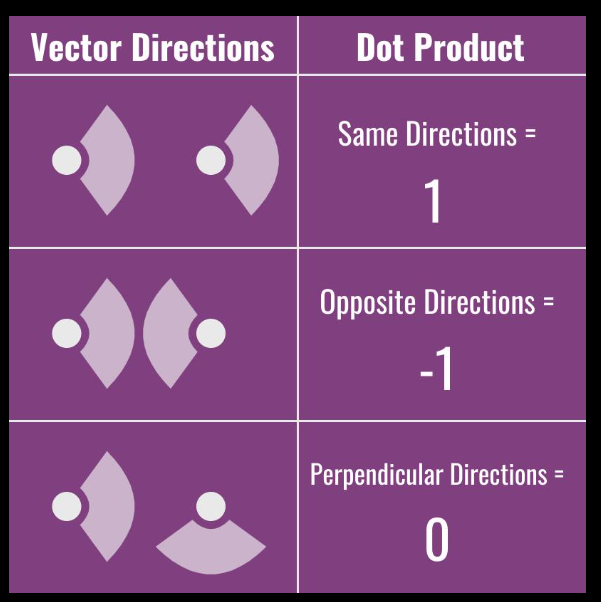
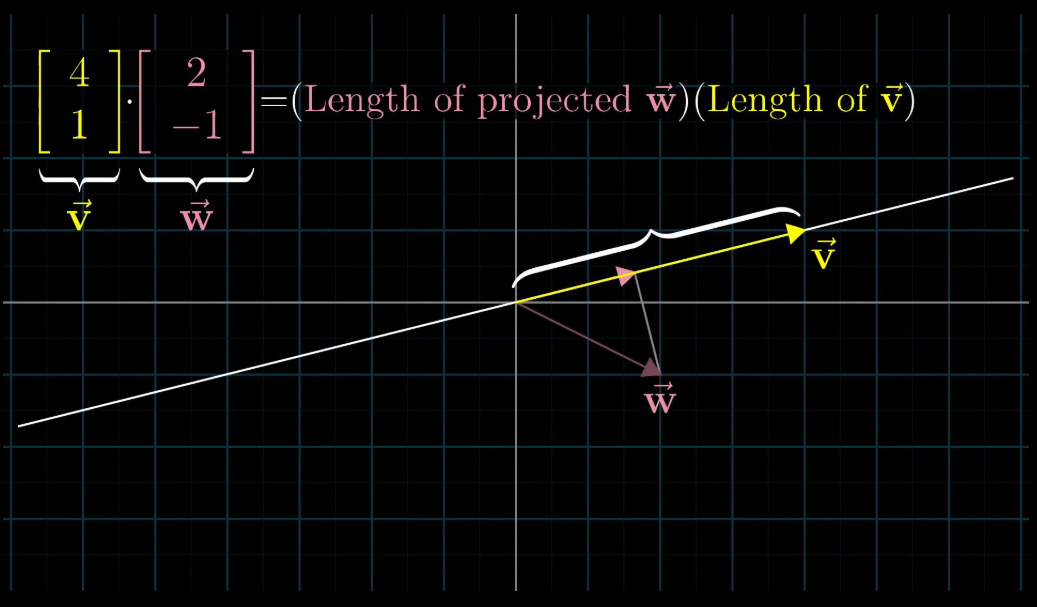


📐 2. Cosine Similarity (only direction)

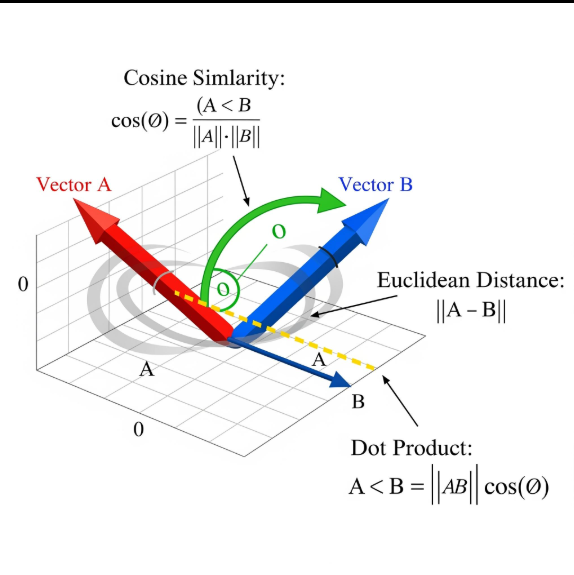
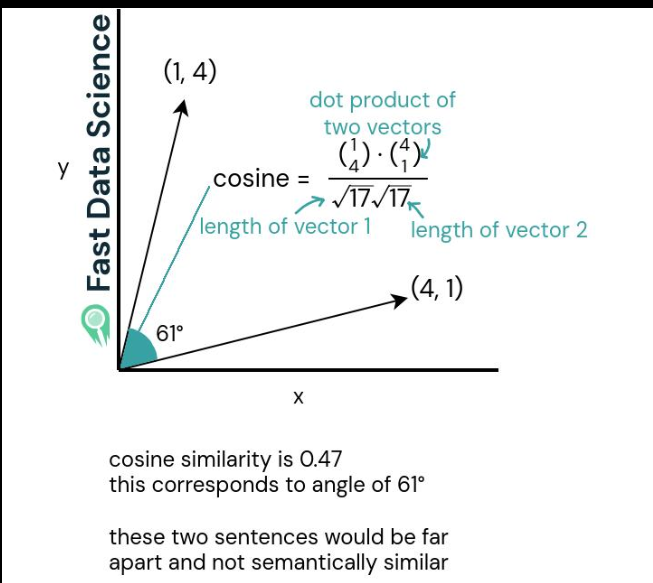
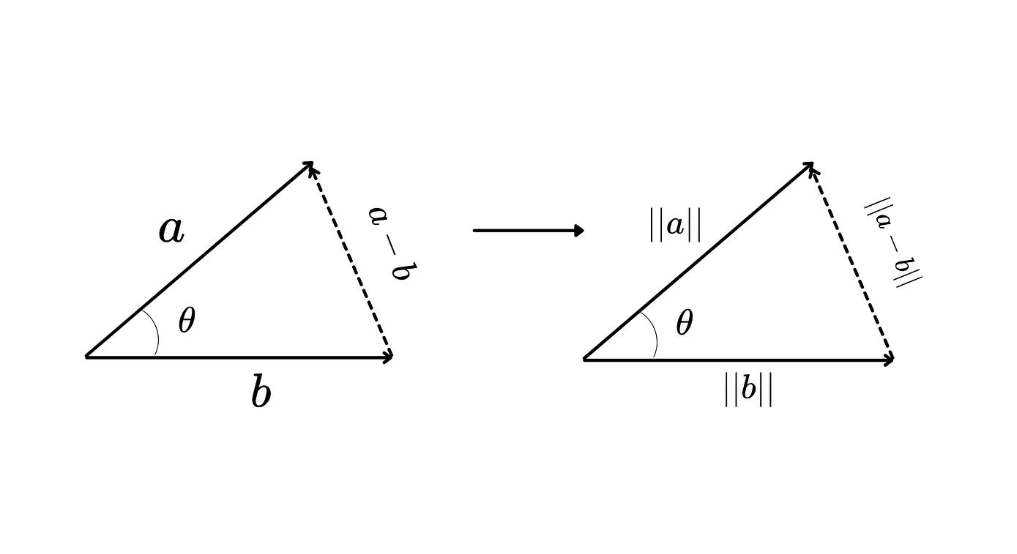
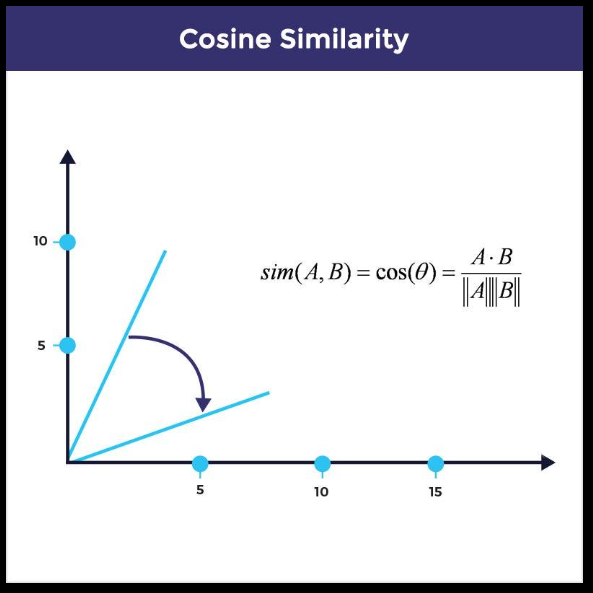


⚔️ 3. Cross Product (perpendicular vector)

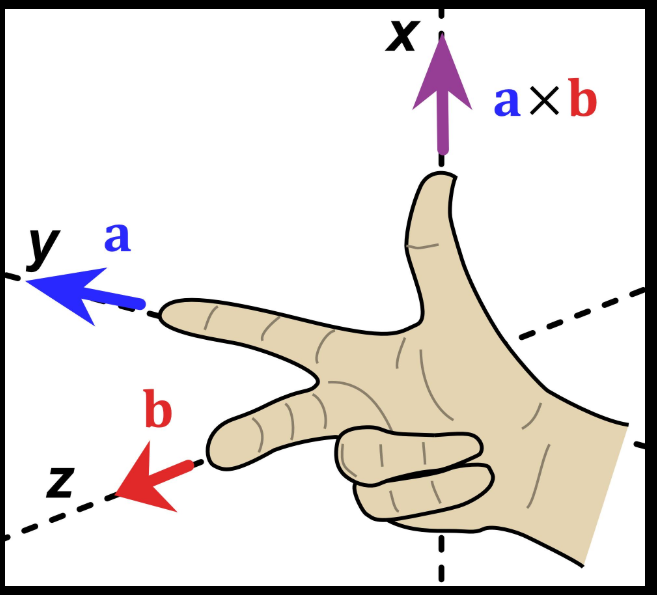
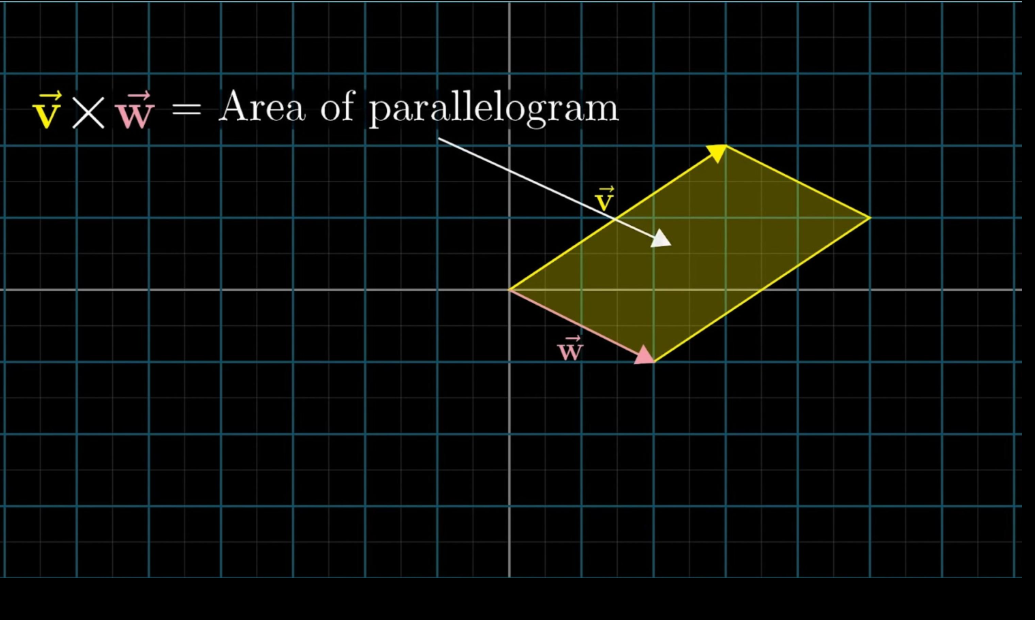
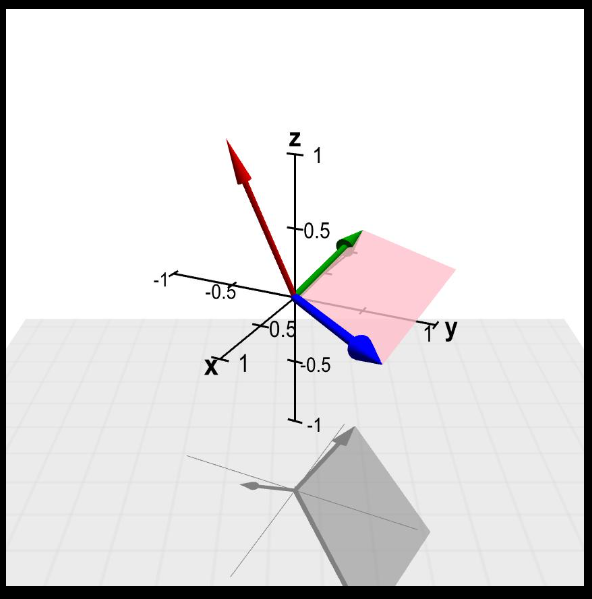
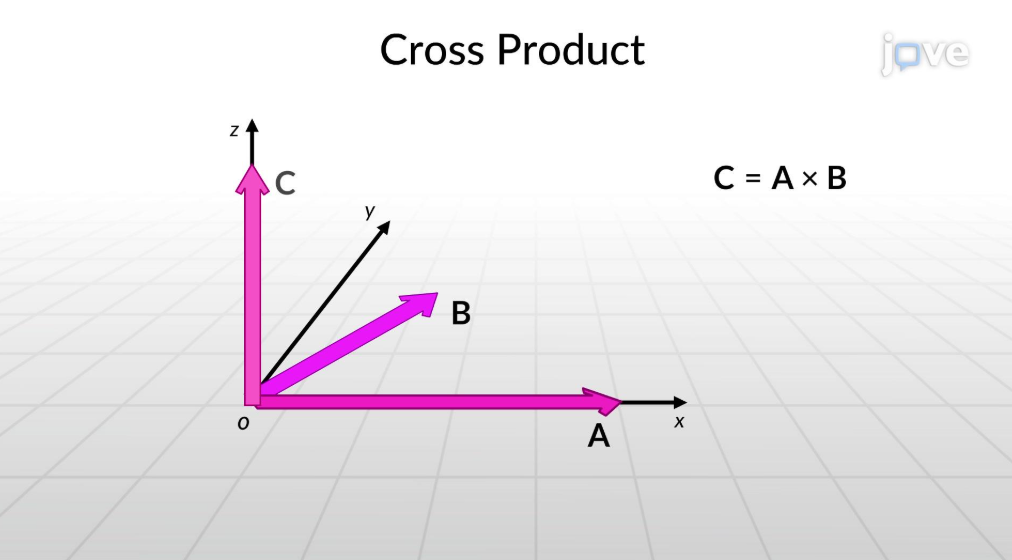